In [1]:
import torch
import torch.nn as nn
import torch.distributions as D
import matplotlib.pyplot as plt
import matplotlib.style as style
import numpy as np
from tqdm import tqdm, trange
from torch.func import jacrev, vmap #type:ignore
from matplotlib.colors import hsv_to_rgb
from conditional_gmm import ConditionalGMM
from posterior_manifold import PosteriorManifold, FisherPosteriorManifold, FisherLogPosteriorManifold, NewFisherLogPosteriorManifold
from riemannian_geometry import lerp
from conformal_ebm import optimize_ebm_geodesic

In [2]:
means = torch.tensor([
         [ 0.7256,  0.6423],
         [-1.1128,  1.2794],
         [-0.5071, -1.7865]])
covs = torch.tensor([
         [[0.3909, 0.0000],
          [0.0000, 0.3909]],
         [[0.4715, 0.0000],
          [0.0000, 0.4715]],
         [[0.4460, 0.0000],
          [0.0000, 0.4460]]])
gmm = ConditionalGMM(2, 3, means=means, covs=covs)
gmm_cuda = ConditionalGMM(2, 3, means=means.cuda(), covs=covs.cuda())

In [3]:
xbounds, ybounds = [-2, 2], [-2, 2]
X, Y = torch.linspace(*xbounds, 50), torch.linspace(*ybounds, 50) #type:ignore
grid = torch.stack(torch.meshgrid(X, Y, indexing='xy'), dim=-1)

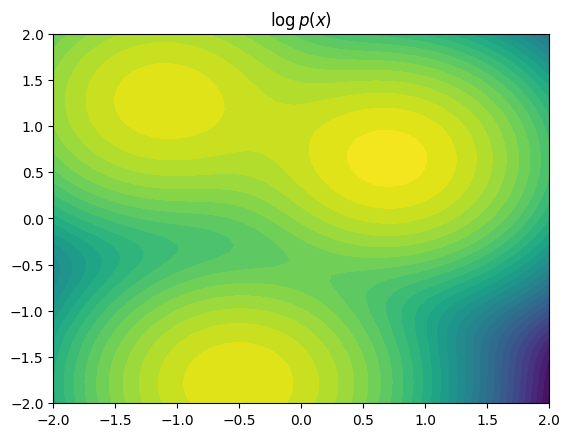

In [7]:
plt.contourf(X, Y, gmm.uncond_log_prob(grid), 30)
plt.title('$\\log p(x)$')
plt.show()

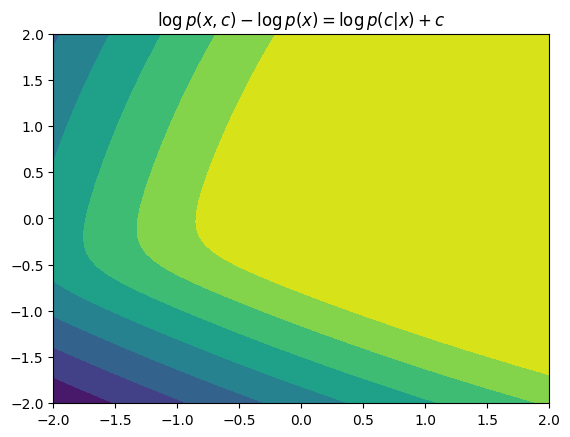

In [8]:
plt.contourf(X, Y, gmm.log_prob(grid)[...,0] - gmm.uncond_log_prob(grid))
plt.title('$\\log p(x,c) - \\log p(x) = \\log p(c|x) + c$')
plt.show()

## Everything in one plot

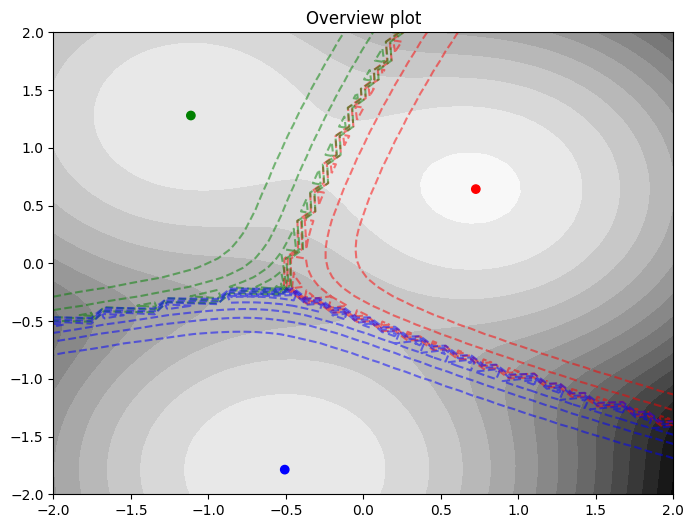

In [4]:
def combined_plot(ax=None):
    if not ax:
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot()
    ax.contourf(X, Y, gmm.uncond_log_prob(grid), 15, cmap='gray')
    colors = ['r', 'g', 'b']
    ax.scatter(*means.T, c=colors)

    prevalent = gmm.log_prob(grid).argmax(dim=-1)

    for i, color in enumerate(colors):
        prevalence_area = prevalent == i
        ax.contour(X, Y, (gmm.log_prob(grid)[...,i] - gmm.uncond_log_prob(grid)) * prevalence_area,
                    colors=color, levels=5, alpha=0.5)
    
combined_plot()
plt.title('Overview plot')
plt.show()

## Finding geodesics using the induced metric
$$p_k(x) = \frac{p(x|c_k)}{p(x)}$$
$$g_{\mu\nu} = \sum_k\nabla_\mu p_k\nabla_\nu p_k$$

### geodesic interpolation with squared difference terms

In [5]:
M = PosteriorManifold(gmm_cuda.posterior)

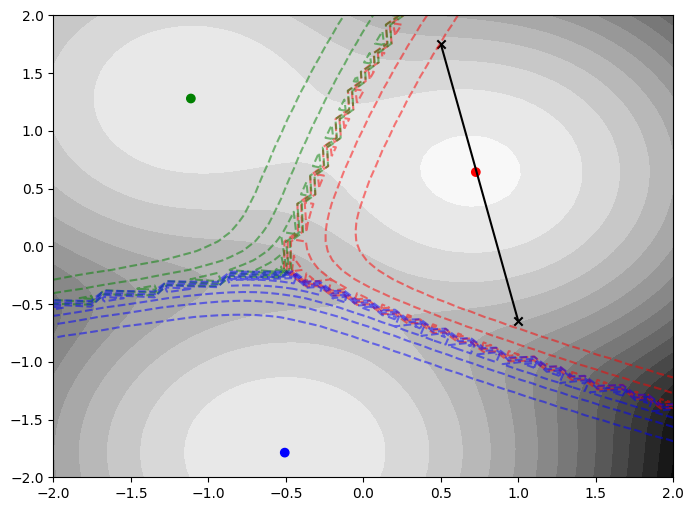

In [11]:
p1, p2 = torch.tensor((1.0, -0.65)), torch.tensor((0.5, 1.75))
combined_plot()
plt.scatter(*torch.stack((p1, p2)).numpy().T, marker='x', c='k')
lin_curve = lerp(p1, p2)
plt.plot(*lin_curve.T, c='k')
plt.show()

optimizing geodesic: 100%|██████████| 10000/10000 [00:26<00:00, 384.61it/s, loss=0.0419]


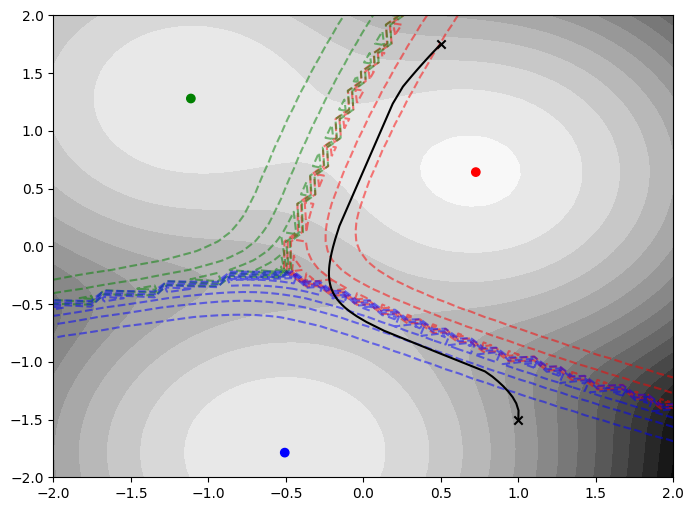

In [13]:
p1, p2 = torch.tensor((1.0, -1.5)), torch.tensor((0.5, 1.75))
geodesic = M.optimize_geodesic(p1, p2, n_segments=50)
combined_plot()
plt.scatter(*torch.stack((p1, p2)).numpy().T, marker='x', c='k')
plt.plot(*geodesic.T, c='k')
plt.show()

### full geodesic workflow

optimizing geodesic: 100%|██████████| 10000/10000 [00:27<00:00, 369.81it/s, loss=0.031]


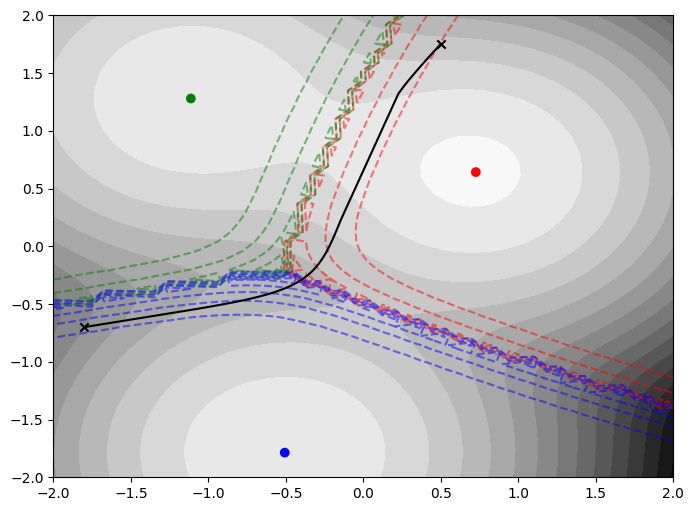

In [18]:
p1, p2 = torch.tensor((-1.8, -0.7)), torch.tensor((0.5, 1.75))
geodesic = M.optimize_geodesic(p1, p2, n_segments=50)
combined_plot()
plt.scatter(*torch.stack((p1, p2)).numpy().T, marker='x', c='k')
plt.plot(*geodesic.T, c='k')
plt.show()

### Karcher mean

optimizing Karcher mean: 100%|██████████| 10000/10000 [00:56<00:00, 177.02it/s, loss=1.95]


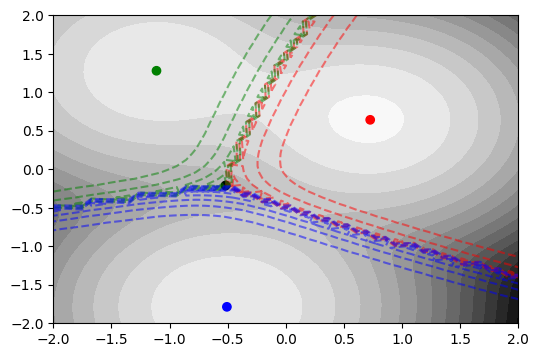

In [9]:
p1, p2, p3 = means
karcher_mean = M.optimize_Karcher_mean(p1, p2, p3)
combined_plot()
plt.scatter(*karcher_mean, c='k')
plt.show()

optimizing Karcher mean: 100%|██████████| 10000/10000 [00:56<00:00, 177.16it/s, loss=0.993]


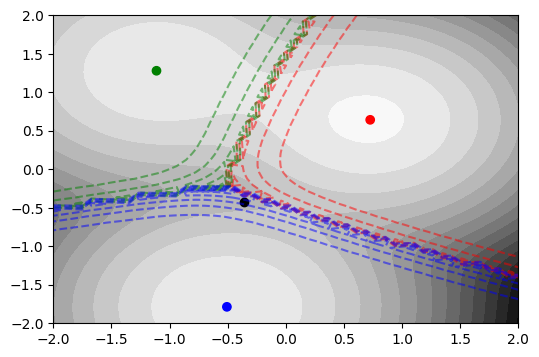

In [ ]:
p1, p2, p3 = torch.tensor((-1.8, -0.7)), torch.tensor((0.5, 1.75)), torch.tensor((1.0, -1.5))
karcher_mean = M.optimize_Karcher_mean(p1, p2, p3)
combined_plot()
plt.scatter(*torch.stack((p1, p2, p3)).numpy().T, marker='x', c='k')
plt.scatter(*karcher_mean, c='k')
plt.show()

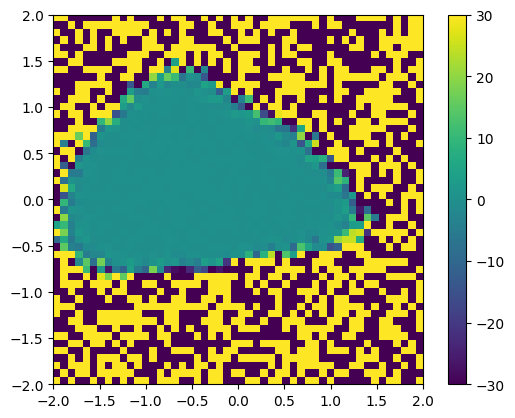

In [ ]:
ric_grid = torch.clamp(M.ric(grid.cuda()).detach().cpu(), min=-30, max=30)
plt.imshow(ric_grid, extent=(*xbounds, *ybounds)) #type:ignore
plt.colorbar()
plt.show()

## Experiments with Fisher-Rao metric on $\Delta^{n-1}$

In [6]:
M_FR = FisherLogPosteriorManifold(gmm_cuda.log_posterior)

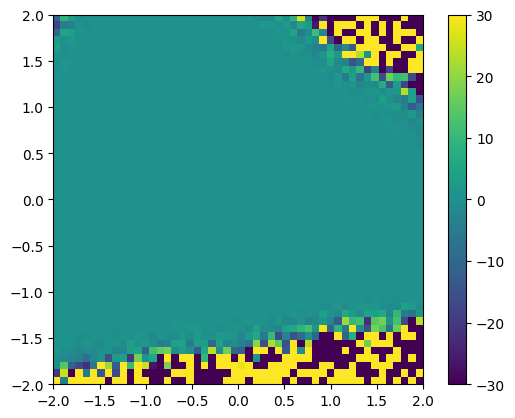

In [7]:
ric_grid = torch.clamp(M_FR.ric(grid.cuda()).detach().cpu(), min=-30, max=30)
plt.imshow(ric_grid, extent=(*xbounds, *ybounds)) #type:ignore
plt.colorbar()
plt.show()

In [10]:
M_FR.ric(torch.tensor((0., 0.), device='cuda'))

tensor(0.5000, device='cuda:0', grad_fn=<ViewBackward0>)

In [7]:
def show_posterior(curve: torch.Tensor, log_posterior, title=None, ax=None, top_n_labels: int | None = None):
    with torch.no_grad():
        posterior = torch.exp(log_posterior(curve.cuda()).cpu())
    if not ax:
        fig = plt.figure()
        ax = fig.add_subplot()
    colors = ['r', 'g', 'b']
    for p, c in zip(posterior.T, colors):
        ax.plot(p, c=c)
    if title: ax.set_title(title)

In [8]:
p1, p2 = torch.tensor((-1.8, -0.7)), torch.tensor((0.5, 1.75))
geodesic = M_FR.optimize_geodesic(p1, p2, n_segments=16, n_subdiv=3, n_iter=2000)

optimizing geodesic: 100%|██████████| 2000/2000 [00:09<00:00, 203.51it/s, loss=0.132]


In [9]:
ebm_geodesic = optimize_ebm_geodesic(p1, p2, gmm_cuda.uncond_log_prob, n_segments=16, n_subdiv=3, n_iter=2000)

optimizing ebm geodesic: 100%|██████████| 2000/2000 [00:10<00:00, 188.66it/s, loss=-3.29]


In [10]:
linline = lerp(p1, p2, n=16)

In [10]:
gmm.posterior(linline)[..., 1].sum()

tensor(8.8171)

In [11]:
gmm.posterior(ebm_geodesic)[..., 1].sum()

tensor(9.1590)

In [12]:
gmm.posterior(geodesic)[..., 1].sum()

tensor(4.1428)

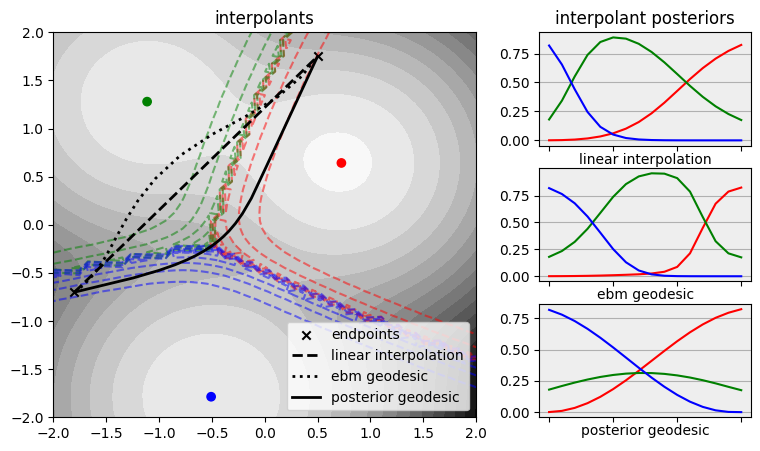

In [11]:
fig = plt.figure(figsize=(9, 5))
gs0 = fig.add_gridspec(ncols=2, width_ratios=(6, 3))
gsr = gs0[1].subgridspec(ncols=1, nrows=3)
axl = fig.add_subplot(gs0[0])
axrt = fig.add_subplot(gsr[0])
axrt.set_xticklabels([])
axrt.set_yticks([0, 0.25, 0.5, 0.75])
axrm = fig.add_subplot(gsr[1])
axrm.set_xticklabels([])
axrm.set_yticks([0, 0.25, 0.5, 0.75])
axrb = fig.add_subplot(gsr[2])
axrb.set_xticklabels([])
axrb.set_yticks([0, 0.25, 0.5, 0.75])
combined_plot(axl)

axl.scatter(*torch.stack((p1, p2)).numpy().T, marker='x', c='k', label='endpoints')
axl.plot(*linline.T, '--k', label='linear interpolation', lw=2)
axl.plot(*ebm_geodesic.T, ':k', label='ebm geodesic', lw=2)
axl.plot(*geodesic.T, 'k', label='posterior geodesic', lw=2)
axl.legend(loc=4)
axl.set_title('interpolants')

show_posterior(linline, gmm_cuda.log_posterior, ax=axrt, title='interpolant posteriors')
axrt.set_xlabel('linear interpolation', labelpad=-2)
axrt.set_facecolor("#EEEEEE"); axrt.grid(True, axis='y')
show_posterior(ebm_geodesic, gmm_cuda.log_posterior, ax=axrm)
axrm.set_xlabel('ebm geodesic', labelpad=-2)
axrm.set_facecolor("#EEEEEE"); axrm.grid(True, axis='y')
show_posterior(geodesic, gmm_cuda.log_posterior, ax=axrb)
axrb.set_xlabel('posterior geodesic', labelpad=-2)
axrb.set_facecolor("#EEEEEE"); axrb.grid(True, axis='y')
plt.show()

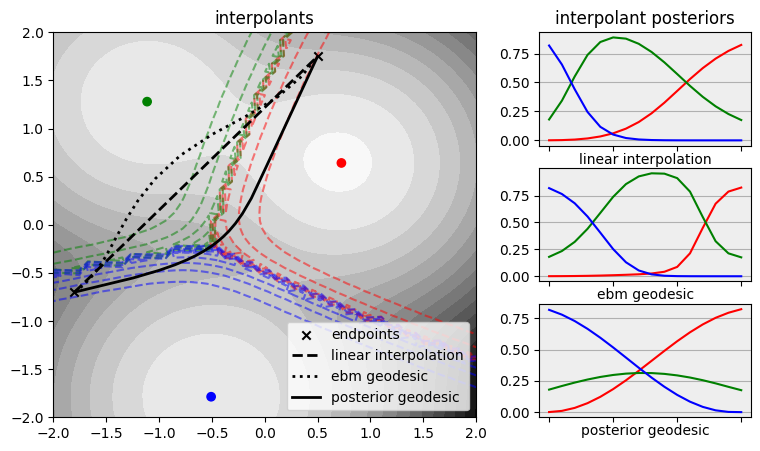

In [13]:
fig = plt.figure(figsize=(9, 5))
gs0 = fig.add_gridspec(ncols=2, width_ratios=(6, 3))
gsr = gs0[1].subgridspec(ncols=1, nrows=3)
axl = fig.add_subplot(gs0[0])
axrt = fig.add_subplot(gsr[0])
axrt.set_xticklabels([])
axrt.set_yticks([0, 0.25, 0.5, 0.75])
axrm = fig.add_subplot(gsr[1])
axrm.set_xticklabels([])
axrm.set_yticks([0, 0.25, 0.5, 0.75])
axrb = fig.add_subplot(gsr[2])
axrb.set_xticklabels([])
axrb.set_yticks([0, 0.25, 0.5, 0.75])
combined_plot(axl)

axl.scatter(*torch.stack((p1, p2)).numpy().T, marker='x', c='k', label='endpoints')
axl.plot(*linline.T, '--k', label='linear interpolation', lw=2)
axl.plot(*ebm_geodesic.T, ':k', label='ebm geodesic', lw=2)
axl.plot(*geodesic.T, 'k', label='posterior geodesic', lw=2)
axl.legend(loc=4)
axl.set_title('interpolants')

show_posterior(linline, gmm_cuda.log_posterior, ax=axrt, title='interpolant posteriors')
axrt.set_xlabel('linear interpolation', labelpad=-2)
axrt.set_facecolor("#EEEEEE"); axrt.grid(True, axis='y')
show_posterior(ebm_geodesic, gmm_cuda.log_posterior, ax=axrm)
axrm.set_xlabel('ebm geodesic', labelpad=-2)
axrm.set_facecolor("#EEEEEE"); axrm.grid(True, axis='y')
show_posterior(geodesic, gmm_cuda.log_posterior, ax=axrb)
axrb.set_xlabel('posterior geodesic', labelpad=-2)
axrb.set_facecolor("#EEEEEE"); axrb.grid(True, axis='y')
plt.savefig('results/gmm_highlight.pdf', bbox_inches='tight')

In [18]:
M_FR.geodesic_deviation(geodesic.detach())

tensor(0.4302, device='cuda:0', grad_fn=<AddBackward0>)

In [23]:
p1, p2 = torch.tensor((-1.8, -0.7)), torch.tensor((0.5, 1.75))
linline = lerp(p1, p2, n=16)
M_FR.geodesic_deviation(linline)

tensor(0.0412, device='cuda:0', grad_fn=<AddBackward0>)

In [27]:
linline.requires_grad_()

tensor([[-1.8000, -0.7000],
        [-1.6467, -0.5367],
        [-1.4933, -0.3733],
        [-1.3400, -0.2100],
        [-1.1867, -0.0467],
        [-1.0333,  0.1167],
        [-0.8800,  0.2800],
        [-0.7267,  0.4433],
        [-0.5733,  0.6067],
        [-0.4200,  0.7700],
        [-0.2667,  0.9333],
        [-0.1133,  1.0967],
        [ 0.0400,  1.2600],
        [ 0.1933,  1.4233],
        [ 0.3467,  1.5867],
        [ 0.5000,  1.7500]], requires_grad=True)

In [32]:
optimizer = torch.optim.Adam([linline])
pbar = trange(250)
for _ in pbar:
    optimizer.zero_grad()
    deviation = M_FR.geodesic_deviation(linline)
    deviation.backward()
    optimizer.step()
    pbar.set_postfix(loss=deviation.item())

100%|██████████| 250/250 [03:33<00:00,  1.17it/s, loss=0.00632]


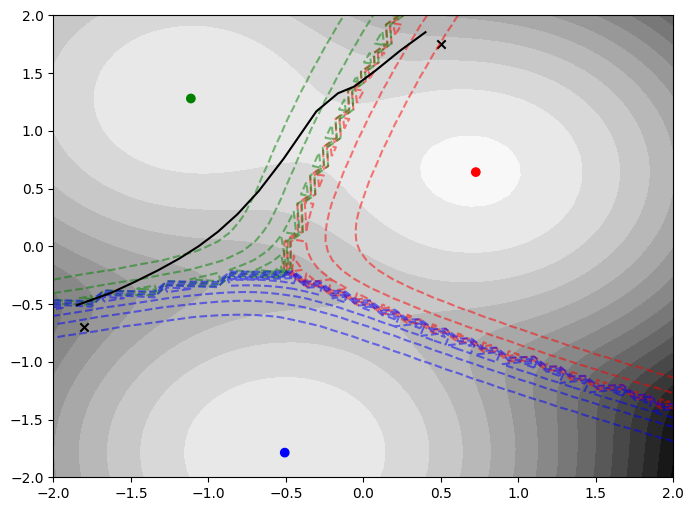

In [33]:
p1, p2 = torch.tensor((-1.8, -0.7)), torch.tensor((0.5, 1.75))
combined_plot()
plt.scatter(*torch.stack((p1, p2)).numpy().T, marker='x', c='k')
plt.plot(*linline.detach().T, c='k')
plt.show()

Computing exponential map:   0%|          | 0/256 [00:00<?, ?it/s]

Computing exponential map: 100%|██████████| 256/256 [00:09<00:00, 28.03it/s]


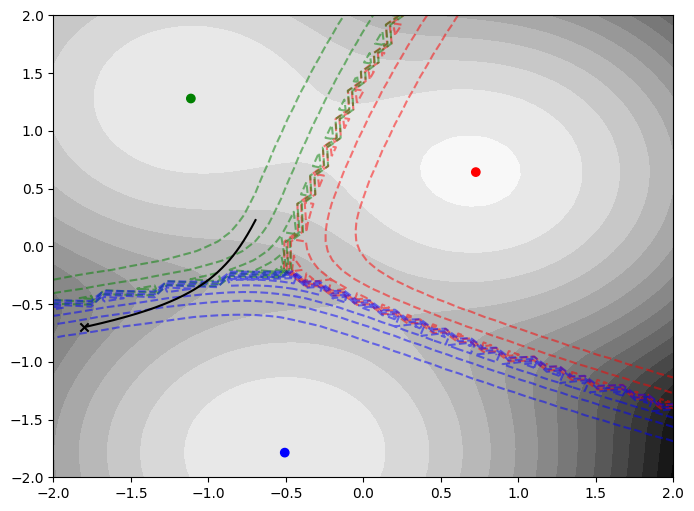

In [17]:
p1, in_dir = torch.tensor((-1.8, -0.7)), torch.tensor((1.0, 0.3))
exp_curve = M_FR.exponential_map(p1, in_dir, factor=8, resolution=32).detach()
combined_plot()
plt.scatter(*p1, marker='x', c='k')
plt.plot(*exp_curve.T, c='k')
plt.show()

optimizing geodesic: 100%|██████████| 10000/10000 [00:28<00:00, 348.76it/s, loss=0.157]


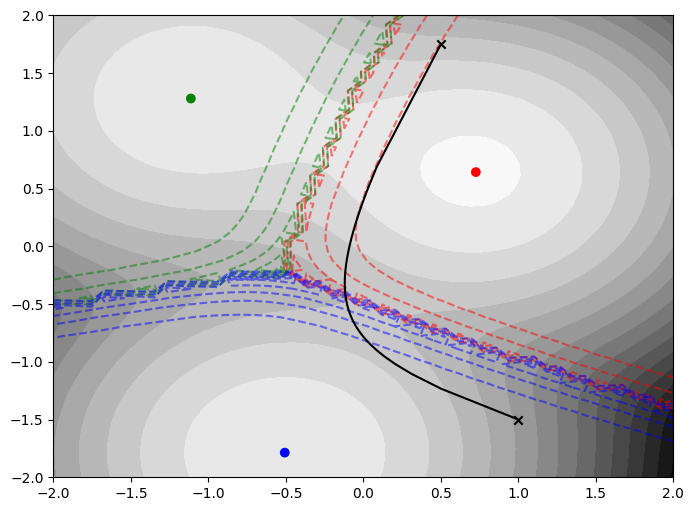

In [19]:
p1, p2 = torch.tensor((1.0, -1.5)), torch.tensor((0.5, 1.75))
geodesic = M_FR.optimize_geodesic(p1, p2, n_segments=50)
combined_plot()
plt.scatter(*torch.stack((p1, p2)).numpy().T, marker='x', c='k')
plt.plot(*geodesic.T, c='k')
plt.show()

## What happens with 4 classes? Curvature?

In [2]:
means4 = torch.tensor([
         [ 0.7256,  0.6423],
         [-1.1128,  1.2794],
         [1.6,  -0.75],
         [-0.5071, -1.7865]])
covs4 = torch.tensor([
         [[0.3909, 0.0000],
          [0.0000, 0.3909]],
         [[0.4715, 0.0000],
          [0.0000, 0.4715]],
         [[0.5715, 0.0000],
          [0.0000, 0.3715]],
         [[0.4460, 0.0000],
          [0.0000, 0.4460]]])
gmm4 = ConditionalGMM(2, 4, means=means4, covs=covs4)
gmm_cuda4 = ConditionalGMM(2, 4, means=means4.cuda(), covs=covs4.cuda())

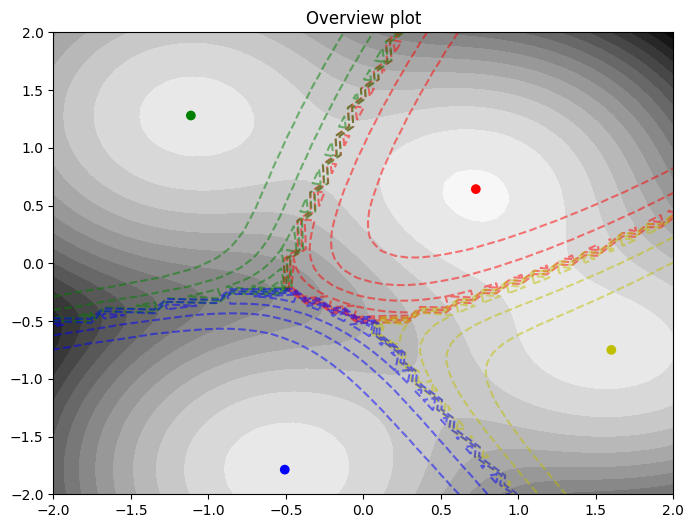

In [6]:
def combined_plot4():
    plt.figure(figsize=(8, 6))
    plt.contourf(X, Y, gmm4.uncond_log_prob(grid), 15, cmap='gray')
    colors = ['r', 'g', 'y', 'b']
    plt.scatter(*means4.T, c=colors)

    prevalent = gmm4.log_prob(grid).argmax(dim=-1)

    for i, color in enumerate(colors):
        prevalence_area = prevalent == i
        plt.contour(X, Y, (gmm4.log_prob(grid)[...,i] - gmm4.uncond_log_prob(grid)) * prevalence_area,
                    colors=color, levels=5, alpha=0.5)
    
combined_plot4()
plt.title('Overview plot')
plt.show()

In [7]:
M_4 = FisherLogPosteriorManifold(gmm_cuda4.log_posterior)

Computing exponential map:   0%|          | 0/64 [00:00<?, ?it/s]

Computing exponential map: 100%|██████████| 64/64 [00:03<00:00, 19.72it/s]


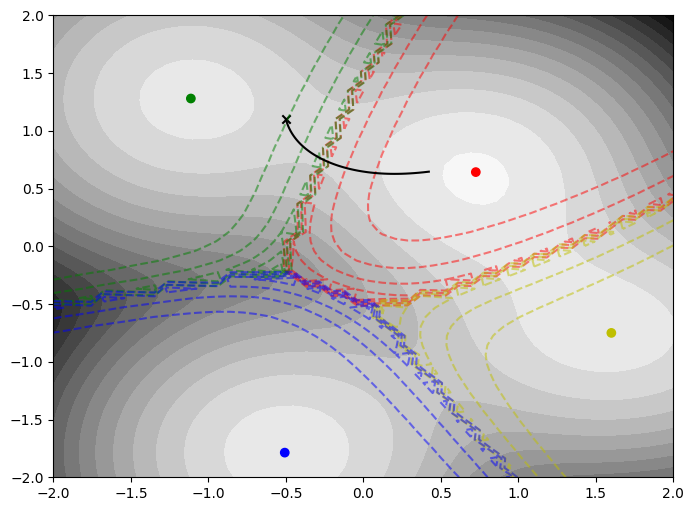

In [31]:
p1, in_dir = torch.tensor((-0.5, 1.1)), torch.tensor((0.2, -1))
exp_curve = M_4.exponential_map(p1, in_dir, factor=2, resolution=32).detach()
combined_plot4()
plt.scatter(*p1, marker='x', c='k')
plt.plot(*exp_curve.T, c='k')
plt.show()

In [8]:
def psd_mat_sqrt(mats: torch.Tensor):
    eigvals, eigvecs = torch.linalg.eigh(mats)
    return torch.einsum('kid, kd, kdj -> kij', eigvecs, torch.sqrt(eigvals), eigvecs.swapaxes(-2, -1))
def unit_circle(resolution: int = 32):
    t = torch.linspace(0, 2*torch.pi, resolution+1)
    return torch.stack((torch.cos(t), torch.sin(t)), dim=-1)
def plot_2d_gmm(means: torch.Tensor, covs: torch.Tensor, scale_fac=1.5, resolution: int=32, color='k'):
    means, covs = means.detach().cpu(), covs.detach().cpu()
    ellipsoids = scale_fac*torch.einsum('kid,rd->irk', psd_mat_sqrt(covs), unit_circle(resolution)) + means.T[:, None, :]
    plt.plot(*ellipsoids, c=color)

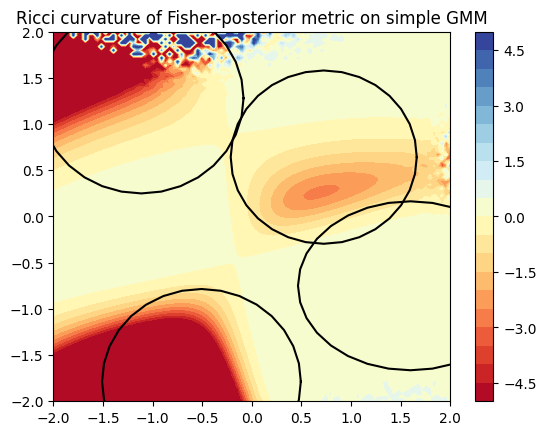

In [14]:
X_c, Y_c = torch.linspace(*xbounds, 100), torch.linspace(*ybounds, 100) #type:ignore
grid_c = torch.stack(torch.meshgrid(X_c, Y_c, indexing='xy')).movedim(0, -1)
ric_grid = torch.clamp(M_4.ric(grid_c.cuda()).detach().cpu(), min=-5, max=5)
plt.contourf(X_c, Y_c, ric_grid, cmap='RdYlBu', levels=20) #type:ignore
plt.colorbar()
plt.title('Ricci curvature of Fisher-posterior metric on simple GMM')
plot_2d_gmm(gmm4.means, gmm4.covs)
plt.xlim(xbounds)
plt.ylim(ybounds)
plt.show()

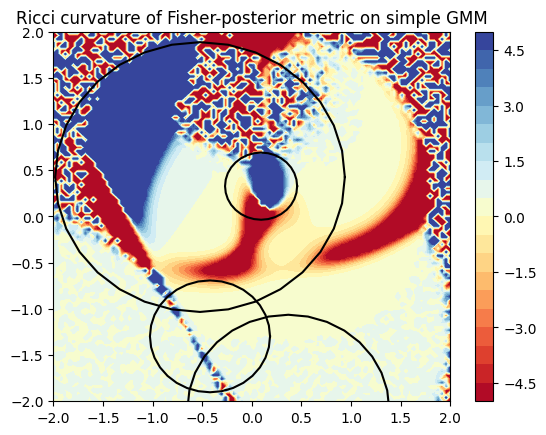

In [34]:
k=4
means_rdm = torch.randn(k, 2)
# covs_rdm = (0.5*torch.randn(k, 2, 2))
# covs_rdm = torch.einsum('kli,klj->kij', covs_rdm, covs_rdm)
covs_rdm = (0.4+0.25*torch.randn(k))[:, None, None] * torch.eye(2)
gmm_rdm = ConditionalGMM(2, k, means=means_rdm, covs=covs_rdm)
gmm_cuda_rdm = ConditionalGMM(2, k, means=means_rdm.cuda(), covs=covs_rdm.cuda())
M_rdm = FisherLogPosteriorManifold(gmm_cuda_rdm.log_posterior)
X_c, Y_c = torch.linspace(*xbounds, 100), torch.linspace(*ybounds, 100) #type:ignore
grid_c = torch.stack(torch.meshgrid(X_c, Y_c, indexing='xy')).movedim(0, -1)
ric_grid = torch.clamp(M_rdm.ric(grid_c.cuda()).detach().cpu(), min=-5, max=5)
plt.contourf(X_c, Y_c, ric_grid, cmap='RdYlBu', levels=20) #type:ignore
plt.colorbar()
plt.title('Ricci curvature of Fisher-posterior metric on simple GMM')
plot_2d_gmm(gmm_rdm.means, gmm_rdm.covs)
plt.xlim(xbounds)
plt.ylim(ybounds)
plt.show()